# Notebook 06 — Modelos preditivos com sentimento (H=1)

> **Objetivo:** estimar os modelos com variáveis de sentimento para prever a inadimplência total em **t+1**, seguindo as configurações já definidas no Notebook 02 e a base consolidada exportada pelo Notebook 05.

Este notebook **não reestima os modelos sem sentimento**. O baseline autorregressivo já foi definido no Notebook 02 e a comparação final entre modelos com e sem sentimento deve ser feita no Notebook 07.

## Decisões metodológicas aplicadas

1. O horizonte de previsão é **H=1**, isto é, a variável-alvo é `inad_total_h1`.
2. A base oficial deste notebook é a `base_completa.csv`, gerada pelo Notebook 05.
3. A base já contém os scores de sentimento no mês de referência **`t`** e seus lags de 1 a 6 meses:
   - `_t`: sentimento observado no mês de referência;
   - `_L1`: sentimento em `t-1`;
   - `_L2`: sentimento em `t-2`;
   - ...
   - `_L6`: sentimento em `t-6`.
4. Os modelos com sentimento usam uma **janela temporal paralela à janela da inadimplência**:
   - **ARIMAX:** mantém `ARIMA(2,1,4)` do Notebook 02. Como `p=2`, cada série de sentimento entra com `t`, `t-1` e `t-2`.
   - **SVR:** mantém `k=1`; portanto, usa `inad_total` e o sentimento em `t`.
   - **XGBoost:** mantém `k=7`; portanto, usa `inad_total`, `inad_total_L1`, ..., `inad_total_L6` e, para o sentimento, `t`, `t-1`, ..., `t-6`.
5. Cada série de sentimento é avaliada **separadamente**, evitando inserir todos os scores no mesmo modelo. Assim, são estimadas versões independentes para cada combinação entre tipo de documento e modelo de sentimento.
6. A comparação é feita pelo erro de previsão no conjunto de teste, com as mesmas métricas usadas no Notebook 02: MAE, RMSE, R², bias e alinhamento previsto versus observado.


In [2]:
# Caso necessário, descomente a linha abaixo no ambiente do Colab/Codespaces.
%pip install pandas numpy matplotlib statsmodels scikit-learn xgboost-cpu



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")


## 1. Funções auxiliares

As funções abaixo padronizam as métricas, a validação temporal e a correção de bias para manter paralelismo com o Notebook 02.


In [4]:
def metricas_regr(y_true, y_pred) -> dict:
    """Calcula métricas de regressão para comparação dos modelos."""
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)

    df_aux = pd.concat([y_true.rename("obs"), y_pred.rename("pred")], axis=1).dropna()

    if len(df_aux) < 2:
        raise ValueError("Não há observações suficientes para calcular as métricas.")

    y_true = df_aux["obs"]
    y_pred = df_aux["pred"]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    bias = float(np.mean(y_true - y_pred))

    lr = LinearRegression().fit(
        np.array(y_true).reshape(-1, 1),
        np.array(y_pred)
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Bias (obs - prev)": bias,
        "Slope pred~obs": float(lr.coef_[0]),
        "Intercept": float(lr.intercept_),
        "N": int(len(df_aux)),
    }


def aplicar_bias(y_true_treino, yhat_treino, yhat_teste):
    """
    Estima o bias no treino e aplica a correção nas previsões de teste.

    Bias = média(obs - previsto) no treino.
    Previsão corrigida = previsão_teste + bias_treino.
    """
    df_bias = pd.concat([
        pd.Series(y_true_treino).rename("obs"),
        pd.Series(yhat_treino).rename("pred")
    ], axis=1).dropna()

    if df_bias.empty:
        return 0.0, pd.Series(yhat_teste).astype(float)

    bias = float((df_bias["obs"] - df_bias["pred"]).mean())
    return bias, pd.Series(yhat_teste).astype(float) + bias


In [5]:
def walk_forward_tabular(
    df,
    feature_cols,
    target_col,
    model_factory_fn,
    start_target_date=None,
    data_ref_col="data_ref",
    data_alvo_col="data_alvo",
    min_train_obs=15,
):
    """
    Validação walk-forward para modelos tabulares.

    Para prever uma linha com referência t, o modelo só pode treinar com linhas
    cujo alvo já seria conhecido no mês t. Por isso, usa-se data_alvo <= data_ref.
    """
    preds = {}
    df = df.sort_values([data_alvo_col, data_ref_col]).reset_index(drop=True).copy()

    if start_target_date is not None:
        start_target_date = pd.to_datetime(start_target_date)

    for i, row in df.iterrows():
        if start_target_date is not None and row[data_alvo_col] < start_target_date:
            continue

        data_ref = row[data_ref_col]

        train_mask = df[data_alvo_col] <= data_ref
        train = df.loc[train_mask, feature_cols + [target_col]].dropna()
        test = row[feature_cols]

        if len(train) < min_train_obs:
            continue
        if test.isna().any() or pd.isna(row[target_col]):
            continue

        model = model_factory_fn()
        model.fit(train[feature_cols], train[target_col])
        preds[i] = float(model.predict(pd.DataFrame([test], columns=feature_cols))[0])

    return pd.Series(preds, name="pred")


In [6]:
def walk_forward_sarimax_exog(
    df,
    target_col,
    exog_cols,
    order,
    start_target_date=None,
    data_alvo_col="data_alvo",
    min_train_obs=24,
    maxiter=150,
):
    """
    Walk-forward para ARIMAX/SARIMAX com variáveis exógenas.

    A cada passo, o scaler das exógenas é ajustado apenas no treino daquele passo.
    """
    preds = {}
    base = (
        df[[data_alvo_col, target_col] + exog_cols]
        .dropna()
        .sort_values(data_alvo_col)
        .drop_duplicates(subset=data_alvo_col, keep="last")
        .reset_index(drop=True)
    )

    if start_target_date is not None:
        start_target_date = pd.to_datetime(start_target_date)

    for i, row in base.iterrows():
        data_alvo = row[data_alvo_col]

        if start_target_date is not None and data_alvo < start_target_date:
            continue
        if i < min_train_obs:
            continue

        treino = base.iloc[:i].copy()
        y_train = treino[target_col].astype(float)
        X_train = treino[exog_cols].astype(float)
        X_fore = base.loc[[i], exog_cols].astype(float)

        try:
            scaler = StandardScaler().fit(X_train)
            X_train_s = scaler.transform(X_train)
            X_fore_s = scaler.transform(X_fore)

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fit = SARIMAX(
                    y_train,
                    exog=X_train_s,
                    order=order,
                    trend="c",
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=maxiter)

                pred = fit.forecast(steps=1, exog=X_fore_s)

            preds[base.index[i]] = float(np.asarray(pred)[0])

        except Exception as exc:
            preds[base.index[i]] = np.nan
            print(f"Falha no ARIMAX para {data_alvo.date()}: {type(exc).__name__} — {exc}")

    return pd.Series(preds, name="pred")


## 2. Carregamento e preparação da base

A base oficial deste notebook é a `base_completa.csv`, pois ela já contém a inadimplência, o alvo em `t+1`, `data_alvo` e as variáveis de sentimento em `t` e em defasagens de 1 a 6 meses.


In [7]:
# Ajuste o caminho se necessário.
possible_paths = [
    Path("base_completa.csv"),
    Path("/content/base_completa.csv"),
    Path("/mnt/data/base_completa (1).csv"),
    Path("/mnt/data/base_completa.csv"),
    Path("/mnt/data/base_completa(1).csv"),
    Path("/mnt/data/base_completa(2).csv"),
]

# Quando há mais de uma base_completa no ambiente, priorizamos a versão que já
# contém as colunas contemporâneas de sentimento (_t), geradas no Notebook 05.
BASE_PATH = None
for candidate in possible_paths:
    if not candidate.exists():
        continue

    preview_cols = pd.read_csv(candidate, nrows=1).columns
    has_sentimento_t = any(re.search(r"_score_.+_t$", c) for c in preview_cols)

    if has_sentimento_t:
        BASE_PATH = candidate
        break

if BASE_PATH is None:
    BASE_PATH = next((p for p in possible_paths if p.exists()), None)

if BASE_PATH is None:
    raise FileNotFoundError("Não encontrei base_completa.csv. Ajuste BASE_PATH com o caminho correto.")

base = pd.read_csv(BASE_PATH)

# Padronização das datas.
for col in ["data", "data_ref", "data_alvo"]:
    if col in base.columns:
        base[col] = pd.to_datetime(base[col])

# Padronização do nome dos lags da inadimplência.
# Algumas versões da base podem trazer inad_total_l1; o Notebook 02 usa inad_total_L1.
rename_lags = {
    f"inad_total_l{i}": f"inad_total_L{i}"
    for i in range(1, 7)
    if f"inad_total_l{i}" in base.columns
}
base = base.rename(columns=rename_lags)

base = base.sort_values("data_alvo").reset_index(drop=True)

print(f"Base carregada: {BASE_PATH}")
print(f"Dimensão: {base.shape[0]} linhas x {base.shape[1]} colunas")
print(f"Período data_alvo: {base['data_alvo'].min().date()} → {base['data_alvo'].max().date()}")
base.head()


Base carregada: base_completa.csv
Dimensão: 77 linhas x 95 colunas
Período data_alvo: 2019-08-01 → 2025-12-01


,data,data_ref,data_alvo,inad_total_h1,inad_total,inad_total_L1,inad_total_L2,inad_total_L3,inad_total_L4,inad_total_L5,...,estatisticas_score_mistral_L4,estatisticas_score_mistral_L5,estatisticas_score_mistral_L6,estatisticas_score_media_t,estatisticas_score_media_L1,estatisticas_score_media_L2,estatisticas_score_media_L3,estatisticas_score_media_L4,estatisticas_score_media_L5,estatisticas_score_media_L6
0,2019-07-01,2019-07-01,2019-08-01,3.04,3.06,2.95,3.05,3.02,2.99,2.91,...,-0.110806,-0.640000,0.289589,-0.235622,-0.339155,-0.427217,-0.340231,-0.399399,-0.504163,-0.306098
1,2019-08-01,2019-08-01,2019-09-01,3.06,3.04,3.06,2.95,3.05,3.02,2.99,...,0.025000,-0.110806,-0.640000,-0.496210,-0.235622,-0.339155,-0.427217,-0.340231,-0.399399,-0.504163
2,2019-09-01,2019-09-01,2019-10-01,3.03,3.06,3.04,3.06,2.95,3.05,3.02,...,-0.410969,0.025000,-0.110806,-0.366679,-0.496210,-0.235622,-0.339155,-0.427217,-0.340231,-0.399399
3,2019-10-01,2019-10-01,2019-11-01,3.00,3.03,3.06,3.04,3.06,2.95,3.05,...,0.112556,-0.410969,0.025000,-0.393281,-0.366679,-0.496210,-0.235622,-0.339155,-0.427217,-0.340231
4,2019-11-01,2019-11-01,2019-12-01,2.94,3.00,3.03,3.06,3.04,3.06,2.95,...,0.186940,0.112556,-0.410969,-0.517378,-0.393281,-0.366679,-0.496210,-0.235622,-0.339155,-0.427217


In [8]:
# =============================================================
# Configurações herdadas do Notebook 02
# =============================================================
HORIZONTE = 1
TARGET_COL = "inad_total_h1"
SPLIT_DATE = "2024-01-01"
split_dt = pd.to_datetime(SPLIT_DATE)

# Configurações definidas no Notebook 02.
ORDEM_ARIMA = (2, 1, 4)
P_ARIMA = ORDEM_ARIMA[0]

# k indica o tamanho da janela histórica usada pelo modelo tabular.
# k=1 -> usa apenas o valor contemporâneo da inadimplência: inad_total.
# k=7 -> usa inad_total + seis lags: inad_total_L1 ... inad_total_L6.
K_SVR = 1
K_XGB = 7

FEATURES_INAD = ["inad_total"] + [f"inad_total_L{i}" for i in range(1, 7)]

# Colunas de sentimento disponíveis: _t e _L1 até _L6.
SENTIMENT_COLS = [
    c for c in base.columns
    if re.search(r"_score_", c) and re.search(r"_(?:t|L[1-6])$", c)
]

SENTIMENT_SERIES_BASES = sorted({
    re.sub(r"_(?:t|L[1-6])$", "", c)
    for c in SENTIMENT_COLS
})

required_cols = ["data_ref", "data_alvo", TARGET_COL] + FEATURES_INAD
missing = [c for c in required_cols if c not in base.columns]
if missing:
    raise ValueError(f"Colunas obrigatórias ausentes: {missing}")

missing_t = [s for s in SENTIMENT_SERIES_BASES if f"{s}_t" not in base.columns]
if missing_t:
    raise ValueError(
        "A base_completa.csv precisa conter as colunas contemporâneas de sentimento (_t). "
        f"Séries sem _t: {missing_t}"
    )

print("=== Configuração herdada do Notebook 02 ===")
print(f"Target: {TARGET_COL}")
print(f"Split por data_alvo: {split_dt.date()}")
print(f"ARIMAX: ordem {ORDEM_ARIMA}; janela de sentimento: t até t-{P_ARIMA}")
print(f"SVR: k={K_SVR}; janela de sentimento: t")
print(f"XGBoost: k={K_XGB}; janela de sentimento: t até t-{K_XGB-1}")
print(f"Total de séries de sentimento identificadas: {len(SENTIMENT_SERIES_BASES)}")
SENTIMENT_SERIES_BASES


=== Configuração herdada do Notebook 02 ===
Target: inad_total_h1
Split por data_alvo: 2024-01-01
ARIMAX: ordem (2, 1, 4); janela de sentimento: t até t-2
SVR: k=1; janela de sentimento: t
XGBoost: k=7; janela de sentimento: t até t-6
Total de séries de sentimento identificadas: 12


['copom_score_bert',
 'copom_score_finbert',
 'copom_score_media',
 'copom_score_mistral',
 'copom_score_nltk',
 'copom_score_textblob',
 'estatisticas_score_bert',
 'estatisticas_score_finbert',
 'estatisticas_score_media',
 'estatisticas_score_mistral',
 'estatisticas_score_nltk',
 'estatisticas_score_textblob']

## 3. Construção das features com sentimento

A função abaixo traduz a regra combinada com o professor:

- Para cada série de sentimento, a coluna `_t` representa o sentimento no próprio mês de referência.
- As colunas `_L1`, `_L2`, ..., `_L6` representam os valores defasados.
- A janela de sentimento usada em cada modelo acompanha a janela histórica usada pela inadimplência.

Assim:

```text
k = 1  → sentimento em t
k = 3  → sentimento em t, t-1 e t-2
k = 7  → sentimento em t, t-1, ..., t-6
```

Além disso, cada série de sentimento é avaliada separadamente. Portanto, o modelo `ARIMAX + copom_score_mistral` usa apenas a janela da série `copom_score_mistral`, e não todas as séries de sentimento ao mesmo tempo.


In [9]:
NOMES_TIPO = {
    "copom": "Atas do Copom",
    "estatisticas": "Relatórios de Estatísticas",
}

NOMES_MODELO_SENT = {
    "nltk": "NLTK/VADER",
    "textblob": "TextBlob",
    "bert": "BERT Multilingual",
    "finbert": "FinBERT-PT-BR",
    "mistral": "Mistral",
    "media": "Média dos Modelos",
}


def inad_features_for_k(k):
    """
    Replica a interpretação do Notebook 02:
    k=1 usa inad_total;
    k=2 usa inad_total e inad_total_L1;
    k=7 usa inad_total até inad_total_L6.
    """
    if k < 1:
        raise ValueError("k deve ser maior ou igual a 1.")
    return FEATURES_INAD[:k]


def sentiment_window_cols(series_base, k):
    """
    Retorna a janela de sentimento de uma série específica.

    k=1 -> _t
    k=3 -> _t, _L1, _L2
    k=7 -> _t, _L1, ..., _L6
    """
    if k < 1:
        raise ValueError("k deve ser maior ou igual a 1.")

    cols = [f"{series_base}_t"]
    max_lag = min(k - 1, 6)
    cols += [f"{series_base}_L{i}" for i in range(1, max_lag + 1)]

    missing = [c for c in cols if c not in base.columns]
    if missing:
        raise ValueError(f"Colunas de sentimento ausentes para {series_base}: {missing}")

    return cols


def sentiment_window_label(k):
    labels = ["t"] + [f"t-{i}" for i in range(1, min(k - 1, 6) + 1)]
    return ", ".join(labels)


def parse_sentiment_series(series_base):
    """
    Extrai metadados a partir de nomes como:
    copom_score_mistral ou estatisticas_score_textblob.
    """
    match = re.match(r"^(copom|estatisticas)_score_(.+)$", series_base)
    if not match:
        return {
            "tipo_relatorio": "indefinido",
            "tipo_relatorio_label": "Indefinido",
            "modelo_sentimento": series_base,
            "modelo_sentimento_label": series_base,
        }

    tipo, modelo = match.groups()
    return {
        "tipo_relatorio": tipo,
        "tipo_relatorio_label": NOMES_TIPO.get(tipo, tipo),
        "modelo_sentimento": modelo,
        "modelo_sentimento_label": NOMES_MODELO_SENT.get(modelo, modelo),
    }


# Janelas de sentimento de acordo com a estrutura temporal de cada modelo.
K_ARIMAX_SENT = P_ARIMA + 1  # p=2 -> t, t-1, t-2
K_SVR_SENT = K_SVR           # k=1 -> t
K_XGB_SENT = K_XGB           # k=7 -> t, ..., t-6

resumo_features = pd.DataFrame([
    {
        "modelo": "ARIMAX",
        "configuracao_notebook02": str(ORDEM_ARIMA),
        "janela_sentimento": sentiment_window_label(K_ARIMAX_SENT),
        "qtd_features_inadimplencia": "incorporada pelo ARIMA",
        "qtd_features_sentimento_por_serie": len(sentiment_window_cols(SENTIMENT_SERIES_BASES[0], K_ARIMAX_SENT)),
        "avaliacao": "uma série de sentimento por vez",
    },
    {
        "modelo": "SVR",
        "configuracao_notebook02": f"k={K_SVR}",
        "janela_sentimento": sentiment_window_label(K_SVR_SENT),
        "qtd_features_inadimplencia": len(inad_features_for_k(K_SVR)),
        "qtd_features_sentimento_por_serie": len(sentiment_window_cols(SENTIMENT_SERIES_BASES[0], K_SVR_SENT)),
        "avaliacao": "uma série de sentimento por vez",
    },
    {
        "modelo": "XGBoost",
        "configuracao_notebook02": f"k={K_XGB}",
        "janela_sentimento": sentiment_window_label(K_XGB_SENT),
        "qtd_features_inadimplencia": len(inad_features_for_k(K_XGB)),
        "qtd_features_sentimento_por_serie": len(sentiment_window_cols(SENTIMENT_SERIES_BASES[0], K_XGB_SENT)),
        "avaliacao": "uma série de sentimento por vez",
    },
])

resumo_features


,modelo,configuracao_notebook02,janela_sentimento,qtd_features_inadimplencia,qtd_features_sentimento_por_serie,avaliacao
0,ARIMAX,"(2, 1, 4)","t, t-1, t-2",incorporada pelo ARIMA,3,uma série de sentimento por vez
1,SVR,k=1,t,1,1,uma série de sentimento por vez
2,XGBoost,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",7,7,uma série de sentimento por vez


In [10]:
# Base comum para modelagem.
# Não fazemos dropna em todas as séries de sentimento ao mesmo tempo, porque cada
# combinação será avaliada separadamente. Assim, evita-se descartar observações
# por ausência em uma série que não será usada naquele modelo específico.

df_model = (
    base[["data_ref", "data_alvo", TARGET_COL] + FEATURES_INAD + SENTIMENT_COLS]
    .sort_values(["data_alvo", "data_ref"])
    .reset_index(drop=True)
)

print("=== Base de modelagem com sentimento ===")
print(f"Total de observações: {len(df_model)}")
print(f"Treino: {df_model.loc[df_model['data_alvo'] < split_dt, 'data_alvo'].min().date()} → "
      f"{df_model.loc[df_model['data_alvo'] < split_dt, 'data_alvo'].max().date()} | "
      f"{(df_model['data_alvo'] < split_dt).sum()} obs")
print(f"Teste:  {df_model.loc[df_model['data_alvo'] >= split_dt, 'data_alvo'].min().date()} → "
      f"{df_model.loc[df_model['data_alvo'] >= split_dt, 'data_alvo'].max().date()} | "
      f"{(df_model['data_alvo'] >= split_dt).sum()} obs")


=== Base de modelagem com sentimento ===
Total de observações: 77
Treino: 2019-08-01 → 2023-12-01 | 53 obs
Teste:  2024-01-01 → 2025-12-01 | 24 obs


## 4. Funções de avaliação por série de sentimento

As funções abaixo estimam os modelos com sentimento **uma série por vez**.

Exemplo:

```text
ARIMAX + copom_score_nltk_t, copom_score_nltk_L1, copom_score_nltk_L2
ARIMAX + copom_score_textblob_t, copom_score_textblob_L1, copom_score_textblob_L2
...
```

A mesma lógica é aplicada ao SVR e ao XGBoost, respeitando a janela histórica definida no Notebook 02.


In [11]:
resultados = []
predicoes_teste = {}


def registrar_resultado(
    familia,
    series_base,
    config_modelo,
    janela_sentimento,
    cols_sentimento,
    cols_inadimplencia,
    y_true_test,
    yhat_test,
    yhat_test_bc,
    bias_estimado,
):
    """Registra métricas sem e com correção de bias."""
    meta = parse_sentiment_series(series_base)
    pred_base_id = f"{familia}|{series_base}|sem_bias"
    pred_bias_id = f"{familia}|{series_base}|com_bias"

    for label_bias, pred_id, y_pred in [
        ("Não", pred_base_id, yhat_test),
        ("Sim", pred_bias_id, yhat_test_bc),
    ]:
        met = metricas_regr(y_true_test, y_pred)
        resultados.append({
            "Família": familia,
            "Modelo": f"{familia} + {meta['tipo_relatorio_label']} + {meta['modelo_sentimento_label']}",
            "Tipo Relatório": meta["tipo_relatorio_label"],
            "Modelo Sentimento": meta["modelo_sentimento_label"],
            "Série Sentimento": series_base,
            "Configuração": config_modelo,
            "Janela Sentimento": janela_sentimento,
            "Features Inadimplência": ", ".join(cols_inadimplencia) if cols_inadimplencia else "ARIMA endógeno",
            "Features Sentimento": ", ".join(cols_sentimento),
            "Com bias": label_bias,
            "Bias estimado treino": bias_estimado if label_bias == "Sim" else np.nan,
            "id_predicao": pred_id,
            **met,
        })

        predicoes_teste[pred_id] = {
            "familia": familia,
            "series_base": series_base,
            "modelo": f"{familia} + {meta['tipo_relatorio_label']} + {meta['modelo_sentimento_label']}",
            "com_bias": label_bias,
            "y_true": pd.Series(y_true_test).copy(),
            "y_pred": pd.Series(y_pred).copy(),
        }


In [12]:
def avaliar_arimax_por_serie(series_base):
    """Estima ARIMAX para uma série de sentimento específica."""
    cols_sent = sentiment_window_cols(series_base, K_ARIMAX_SENT)

    df_local = (
        df_model[["data_alvo", TARGET_COL] + cols_sent]
        .dropna()
        .sort_values("data_alvo")
        .reset_index(drop=True)
    )

    df_train = df_local[df_local["data_alvo"] < split_dt].reset_index(drop=True)

    yhat_train = walk_forward_sarimax_exog(
        df=df_train,
        target_col=TARGET_COL,
        exog_cols=cols_sent,
        order=ORDEM_ARIMA,
        start_target_date=None,
        min_train_obs=24,
        maxiter=150,
    )

    yhat_test = walk_forward_sarimax_exog(
        df=df_local,
        target_col=TARGET_COL,
        exog_cols=cols_sent,
        order=ORDEM_ARIMA,
        start_target_date=split_dt,
        min_train_obs=24,
        maxiter=150,
    )

    if yhat_test.dropna().empty:
        print(f"ARIMAX — sem previsões válidas para {series_base}.")
        return

    y_true_train = df_train.loc[yhat_train.index, TARGET_COL]
    y_true_test = df_local.loc[yhat_test.index, TARGET_COL]

    bias, yhat_test_bc = aplicar_bias(
        y_true_treino=y_true_train,
        yhat_treino=yhat_train,
        yhat_teste=yhat_test,
    )

    registrar_resultado(
        familia="ARIMAX",
        series_base=series_base,
        config_modelo=f"ARIMA{ORDEM_ARIMA}",
        janela_sentimento=sentiment_window_label(K_ARIMAX_SENT),
        cols_sentimento=cols_sent,
        cols_inadimplencia=[],
        y_true_test=y_true_test,
        yhat_test=yhat_test,
        yhat_test_bc=yhat_test_bc,
        bias_estimado=bias,
    )


In [13]:
def criar_svr():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.05))
    ])


def criar_xgboost():
    return XGBRegressor(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective="reg:squarederror",
    )


def avaliar_tabular_por_serie(
    familia,
    series_base,
    k_modelo,
    k_sentimento,
    model_factory_fn,
    min_train_obs=15,
):
    """Estima SVR ou XGBoost para uma série de sentimento específica."""
    cols_inad = inad_features_for_k(k_modelo)
    cols_sent = sentiment_window_cols(series_base, k_sentimento)
    feature_cols = cols_inad + cols_sent

    df_local = (
        df_model[["data_ref", "data_alvo", TARGET_COL] + feature_cols]
        .dropna()
        .sort_values(["data_alvo", "data_ref"])
        .reset_index(drop=True)
    )

    df_train = df_local[df_local["data_alvo"] < split_dt].reset_index(drop=True)

    yhat_train = walk_forward_tabular(
        df=df_train,
        feature_cols=feature_cols,
        target_col=TARGET_COL,
        model_factory_fn=model_factory_fn,
        start_target_date=None,
        min_train_obs=min_train_obs,
    )

    yhat_test = walk_forward_tabular(
        df=df_local,
        feature_cols=feature_cols,
        target_col=TARGET_COL,
        model_factory_fn=model_factory_fn,
        start_target_date=split_dt,
        min_train_obs=min_train_obs,
    )

    if yhat_test.dropna().empty:
        print(f"{familia} — sem previsões válidas para {series_base}.")
        return

    y_true_train = df_train.loc[yhat_train.index, TARGET_COL]
    y_true_test = df_local.loc[yhat_test.index, TARGET_COL]

    bias, yhat_test_bc = aplicar_bias(
        y_true_treino=y_true_train,
        yhat_treino=yhat_train,
        yhat_teste=yhat_test,
    )

    registrar_resultado(
        familia=familia,
        series_base=series_base,
        config_modelo=f"k={k_modelo}",
        janela_sentimento=sentiment_window_label(k_sentimento),
        cols_sentimento=cols_sent,
        cols_inadimplencia=cols_inad,
        y_true_test=y_true_test,
        yhat_test=yhat_test,
        yhat_test_bc=yhat_test_bc,
        bias_estimado=bias,
    )


## 5. ARIMAX com sentimento

O ARIMAX mantém a estrutura `ARIMA(2,1,4)` definida no Notebook 02. A inclusão do sentimento segue a janela temporal da componente autorregressiva: como `p=2`, cada série de sentimento entra com:

```text
sentimento em t, sentimento em t-1 e sentimento em t-2
```

Não há nova seleção de ordem ARIMA, nem seleção oportunista de lag de sentimento nesta etapa. O mesmo critério é aplicado a todas as séries de sentimento.


In [14]:
print("=== ARIMAX com sentimento ===")
print(f"Ordem usada: {ORDEM_ARIMA}")
print(f"Janela de sentimento por série: {sentiment_window_label(K_ARIMAX_SENT)}")
print(f"Total de séries avaliadas: {len(SENTIMENT_SERIES_BASES)}")

# Evita duplicação caso esta célula seja executada mais de uma vez.
resultados = [r for r in resultados if r.get("Família") != "ARIMAX"]
for k in list(predicoes_teste.keys()):
    if k.startswith("ARIMAX|"):
        del predicoes_teste[k]

for series_base in SENTIMENT_SERIES_BASES:
    print(f"Estimando ARIMAX com {series_base}...")
    avaliar_arimax_por_serie(series_base)

_cols_exib = [
    "Modelo Sentimento", "Tipo Relatório", "Configuração",
    "Janela Sentimento", "Com bias", "RMSE", "MAE", "R2",
    "Bias (obs - prev)", "Slope pred~obs", "N",
]

resultado_arimax = (
    pd.DataFrame(resultados)
    .query("Família == 'ARIMAX' and `Com bias` == 'Sim'")
    .sort_values("RMSE")
    .head(3)
    .reset_index(drop=True)
)
resultado_arimax.index += 1  # ranking começa em 1
resultado_arimax.index.name = "Rank"

print("\n--- Top 3 ARIMAX (com bias, menor RMSE) ---")
display(resultado_arimax[_cols_exib].round(6))


=== ARIMAX com sentimento ===
Ordem usada: (2, 1, 4)
Janela de sentimento por série: t, t-1, t-2
Total de séries avaliadas: 12
Estimando ARIMAX com copom_score_bert...


Estimando ARIMAX com copom_score_finbert...
Estimando ARIMAX com copom_score_media...
Estimando ARIMAX com copom_score_mistral...
Estimando ARIMAX com copom_score_nltk...
Estimando ARIMAX com copom_score_textblob...
Estimando ARIMAX com estatisticas_score_bert...
Estimando ARIMAX com estatisticas_score_finbert...
Estimando ARIMAX com estatisticas_score_media...
Estimando ARIMAX com estatisticas_score_mistral...
Estimando ARIMAX com estatisticas_score_nltk...
Estimando ARIMAX com estatisticas_score_textblob...

--- Top 3 ARIMAX (com bias, menor RMSE) ---


,Modelo Sentimento,Tipo Relatório,Configuração,Janela Sentimento,Com bias,RMSE,MAE,R2,Bias (obs - prev),Slope pred~obs,N
Rank,,,,,,,,,,,
1,Mistral,Atas do Copom,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.085196,0.065200,0.933125,-0.002722,0.945532,24
2,BERT Multilingual,Relatórios de Estatísticas,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.085941,0.067594,0.931951,0.005082,0.938433,24
3,TextBlob,Atas do Copom,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.087674,0.069984,0.929177,0.011456,0.949129,24


## 6. SVR com sentimento

O SVR usa a mesma configuração selecionada no Notebook 02: `k=1`. Assim, entram:

- `inad_total`, que representa a inadimplência observada em `t`;
- a série de sentimento em `t`.

Cada score textual é avaliado separadamente.


In [15]:
print("=== SVR com sentimento ===")
print(f"k usado: {K_SVR}")
print(f"Features de inadimplência: {inad_features_for_k(K_SVR)}")
print(f"Janela de sentimento por série: {sentiment_window_label(K_SVR_SENT)}")
print(f"Total de séries avaliadas: {len(SENTIMENT_SERIES_BASES)}")

# Evita duplicação caso esta célula seja executada mais de uma vez.
resultados = [r for r in resultados if r.get("Família") != "SVR"]
for k in list(predicoes_teste.keys()):
    if k.startswith("SVR|"):
        del predicoes_teste[k]

for series_base in SENTIMENT_SERIES_BASES:
    print(f"Estimando SVR com {series_base}...")
    avaliar_tabular_por_serie(
        familia="SVR",
        series_base=series_base,
        k_modelo=K_SVR,
        k_sentimento=K_SVR_SENT,
        model_factory_fn=criar_svr,
        min_train_obs=15,
    )

_cols_exib = [
    "Modelo Sentimento", "Tipo Relatório", "Configuração",
    "Janela Sentimento", "Com bias", "RMSE", "MAE", "R2",
    "Bias (obs - prev)", "Slope pred~obs", "N",
]

resultado_svr = (
    pd.DataFrame(resultados)
    .query("Família == 'SVR' and `Com bias` == 'Sim'")
    .sort_values("RMSE")
    .head(3)
    .reset_index(drop=True)
)
resultado_svr.index += 1
resultado_svr.index.name = "Rank"

print("\n--- Top 3 SVR (com bias, menor RMSE) ---")
display(resultado_svr[_cols_exib].round(6))


=== SVR com sentimento ===
k usado: 1
Features de inadimplência: ['inad_total']
Janela de sentimento por série: t
Total de séries avaliadas: 12
Estimando SVR com copom_score_bert...
Estimando SVR com copom_score_finbert...
Estimando SVR com copom_score_media...
Estimando SVR com copom_score_mistral...
Estimando SVR com copom_score_nltk...
Estimando SVR com copom_score_textblob...
Estimando SVR com estatisticas_score_bert...
Estimando SVR com estatisticas_score_finbert...
Estimando SVR com estatisticas_score_media...
Estimando SVR com estatisticas_score_mistral...
Estimando SVR com estatisticas_score_nltk...
Estimando SVR com estatisticas_score_textblob...

--- Top 3 SVR (com bias, menor RMSE) ---


,Modelo Sentimento,Tipo Relatório,Configuração,Janela Sentimento,Com bias,RMSE,MAE,R2,Bias (obs - prev),Slope pred~obs,N
Rank,,,,,,,,,,,
1,Média dos Modelos,Atas do Copom,k=1,t,Sim,0.128476,0.101433,0.847920,0.026321,0.819569,24
2,TextBlob,Relatórios de Estatísticas,k=1,t,Sim,0.150715,0.117125,0.790714,-0.013323,0.829713,24
3,Mistral,Atas do Copom,k=1,t,Sim,0.153328,0.121994,0.783394,0.005764,0.845823,24


## 7. XGBoost com sentimento

O XGBoost usa a mesma configuração selecionada no Notebook 02: `k=7`. Assim, entram:

- `inad_total`, `inad_total_L1`, ..., `inad_total_L6`;
- a série de sentimento em `t`, `t-1`, ..., `t-6`.

Cada score textual é avaliado separadamente.


In [16]:
print("=== XGBoost com sentimento ===")
print(f"k usado: {K_XGB}")
print(f"Features de inadimplência: {inad_features_for_k(K_XGB)}")
print(f"Janela de sentimento por série: {sentiment_window_label(K_XGB_SENT)}")
print(f"Total de séries avaliadas: {len(SENTIMENT_SERIES_BASES)}")

# Evita duplicação caso esta célula seja executada mais de uma vez.
resultados = [r for r in resultados if r.get("Família") != "XGBoost"]
for k in list(predicoes_teste.keys()):
    if k.startswith("XGBoost|"):
        del predicoes_teste[k]

for series_base in SENTIMENT_SERIES_BASES:
    print(f"Estimando XGBoost com {series_base}...")
    avaliar_tabular_por_serie(
        familia="XGBoost",
        series_base=series_base,
        k_modelo=K_XGB,
        k_sentimento=K_XGB_SENT,
        model_factory_fn=criar_xgboost,
        min_train_obs=15,
    )

_cols_exib = [
    "Modelo Sentimento", "Tipo Relatório", "Configuração",
    "Janela Sentimento", "Com bias", "RMSE", "MAE", "R2",
    "Bias (obs - prev)", "Slope pred~obs", "N",
]

resultado_xgb = (
    pd.DataFrame(resultados)
    .query("Família == 'XGBoost' and `Com bias` == 'Sim'")
    .sort_values("RMSE")
    .head(3)
    .reset_index(drop=True)
)
resultado_xgb.index += 1
resultado_xgb.index.name = "Rank"

print("\n--- Top 3 XGBoost (com bias, menor RMSE) ---")
display(resultado_xgb[_cols_exib].round(6))


=== XGBoost com sentimento ===
k usado: 7
Features de inadimplência: ['inad_total', 'inad_total_L1', 'inad_total_L2', 'inad_total_L3', 'inad_total_L4', 'inad_total_L5', 'inad_total_L6']
Janela de sentimento por série: t, t-1, t-2, t-3, t-4, t-5, t-6
Total de séries avaliadas: 12
Estimando XGBoost com copom_score_bert...
Estimando XGBoost com copom_score_finbert...
Estimando XGBoost com copom_score_media...
Estimando XGBoost com copom_score_mistral...
Estimando XGBoost com copom_score_nltk...
Estimando XGBoost com copom_score_textblob...
Estimando XGBoost com estatisticas_score_bert...
Estimando XGBoost com estatisticas_score_finbert...
Estimando XGBoost com estatisticas_score_media...
Estimando XGBoost com estatisticas_score_mistral...
Estimando XGBoost com estatisticas_score_nltk...
Estimando XGBoost com estatisticas_score_textblob...

--- Top 3 XGBoost (com bias, menor RMSE) ---


,Modelo Sentimento,Tipo Relatório,Configuração,Janela Sentimento,Com bias,RMSE,MAE,R2,Bias (obs - prev),Slope pred~obs,N
Rank,,,,,,,,,,,
1,Mistral,Atas do Copom,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",Sim,0.122842,0.104140,0.860967,-0.030506,0.802859,24
2,NLTK/VADER,Atas do Copom,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",Sim,0.123842,0.104797,0.858693,-0.007657,0.775456,24
3,Mistral,Relatórios de Estatísticas,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",Sim,0.125332,0.101706,0.855274,-0.005490,0.728642,24


## 8. Comparativo dos modelos com sentimento

As tabelas abaixo exibem o **top 3 por família de modelo** (ARIMAX, SVR, XGBoost), ranqueados pelo menor RMSE no conjunto de teste, considerando apenas versões **com correção de bias**.

A comparação contra os modelos sem sentimento (baseline) deve ser feita no Notebook 07.


In [21]:
# ─────────────────────────────────────────────────────────────
# Comparativo geral: todas as combinações ordenadas por RMSE
# ─────────────────────────────────────────────────────────────
comparativo_com_sentimento = (
    pd.DataFrame(resultados)
    .sort_values("RMSE")
    .reset_index(drop=True)
)
comparativo_com_sentimento["Ranking RMSE"] = comparativo_com_sentimento.index + 1

# Colunas reorganizadas: identificação → configuração → métricas
COLS_TABELA = [
    "Ranking RMSE",
    "Família",
    "Tipo Relatório",
    "Modelo Sentimento",
    "Configuração",
    "Janela Sentimento",
    "Com bias",
    "RMSE",
    "MAE",
    "R2",
    "Bias (obs - prev)",
    "Slope pred~obs",
    "N",
]

# ─────────────────────────────────────────────────────────────
# Top 3 por família e por tipo de relatório, com bias
# groupby().head(3) preserva todas as colunas
# ─────────────────────────────────────────────────────────────
_base_todos = (
    comparativo_com_sentimento
    .query("`Com bias` == 'Sim'")
    .sort_values(["Tipo Relatório", "Família", "RMSE"])
)

top3_todos = (
    _base_todos
    .groupby(["Tipo Relatório", "Família"], sort=False)
    .head(3)
    .reset_index(drop=True)
)

# Rank local dentro de cada grupo Tipo Relatório × Família (1, 2, 3)
top3_todos["Ranking"] = top3_todos.groupby(["Tipo Relatório", "Família"]).cumcount() + 1

cols_top3 = [
    "Ranking", "Tipo Relatório", "Família", "Modelo Sentimento", "Configuração",
    "Janela Sentimento", "RMSE", "MAE", "R2", "Bias (obs - prev)", "Slope pred~obs", "N",
]

for tipo in top3_todos["Tipo Relatório"].unique():
    print(f"\n=== Top 3 por família — {tipo} (com bias) ===")
    subset = top3_todos[top3_todos["Tipo Relatório"] == tipo]
    display(subset[cols_top3].reset_index(drop=True).round(6))

# Mantém top3_copom para compatibilidade com o loop de gráficos da célula 27
top3_copom = top3_todos[top3_todos["Tipo Relatório"] == "Atas do Copom"].reset_index(drop=True)


=== Top 3 por família — Atas do Copom (com bias) ===


,Ranking,Tipo Relatório,Família,Modelo Sentimento,Configuração,Janela Sentimento,RMSE,MAE,R2,Bias (obs - prev),Slope pred~obs,N
0,1,Atas do Copom,ARIMAX,Mistral,"ARIMA(2, 1, 4)","t, t-1, t-2",0.085196,0.065200,0.933125,-0.002722,0.945532,24
1,2,Atas do Copom,ARIMAX,TextBlob,"ARIMA(2, 1, 4)","t, t-1, t-2",0.087674,0.069984,0.929177,0.011456,0.949129,24
2,3,Atas do Copom,ARIMAX,BERT Multilingual,"ARIMA(2, 1, 4)","t, t-1, t-2",0.089664,0.069656,0.925927,-0.005289,0.939685,24
3,1,Atas do Copom,SVR,Média dos Modelos,k=1,t,0.128476,0.101433,0.847920,0.026321,0.819569,24
4,2,Atas do Copom,SVR,Mistral,k=1,t,0.153328,0.121994,0.783394,0.005764,0.845823,24
5,3,Atas do Copom,SVR,FinBERT-PT-BR,k=1,t,0.162714,0.117031,0.756065,0.020399,0.732933,24
6,1,Atas do Copom,XGBoost,Mistral,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",0.122842,0.104140,0.860967,-0.030506,0.802859,24
7,2,Atas do Copom,XGBoost,NLTK/VADER,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",0.123842,0.104797,0.858693,-0.007657,0.775456,24
8,3,Atas do Copom,XGBoost,Média dos Modelos,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",0.126741,0.107061,0.852001,-0.031649,0.754555,24



=== Top 3 por família — Relatórios de Estatísticas (com bias) ===


,Ranking,Tipo Relatório,Família,Modelo Sentimento,Configuração,Janela Sentimento,RMSE,MAE,R2,Bias (obs - prev),Slope pred~obs,N
0,1,Relatórios de Estatísticas,ARIMAX,BERT Multilingual,"ARIMA(2, 1, 4)","t, t-1, t-2",0.085941,0.067594,0.931951,0.005082,0.938433,24
1,2,Relatórios de Estatísticas,ARIMAX,TextBlob,"ARIMA(2, 1, 4)","t, t-1, t-2",0.106412,0.081910,0.895670,-0.011457,0.932257,24
2,3,Relatórios de Estatísticas,ARIMAX,FinBERT-PT-BR,"ARIMA(2, 1, 4)","t, t-1, t-2",0.108293,0.082048,0.891950,-0.003441,0.968048,24
3,1,Relatórios de Estatísticas,SVR,TextBlob,k=1,t,0.150715,0.117125,0.790714,-0.013323,0.829713,24
4,2,Relatórios de Estatísticas,SVR,NLTK/VADER,k=1,t,0.154584,0.119932,0.779830,0.062819,0.812635,24
5,3,Relatórios de Estatísticas,SVR,BERT Multilingual,k=1,t,0.161158,0.122791,0.760708,0.013252,0.748842,24
6,1,Relatórios de Estatísticas,XGBoost,Mistral,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",0.125332,0.101706,0.855274,-0.005490,0.728642,24
7,2,Relatórios de Estatísticas,XGBoost,BERT Multilingual,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",0.125677,0.103978,0.854476,0.001665,0.716506,24
8,3,Relatórios de Estatísticas,XGBoost,TextBlob,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",0.126061,0.101445,0.853584,-0.020835,0.722302,24


In [22]:
# ─────────────────────────────────────────────────────────────
# Melhor modelo por família e por tipo de relatório (com bias)
# ─────────────────────────────────────────────────────────────
melhores_todos = (
    comparativo_com_sentimento
    .query("`Com bias` == 'Sim'")
    .sort_values("RMSE")
    .groupby(["Tipo Relatório", "Família"], as_index=False)
    .first()
    .sort_values(["Tipo Relatório", "RMSE"])
    .reset_index(drop=True)
)

# Renomeia colunas para exibição mais clara
COLS_RENAME = {
    "Ranking RMSE":     "Rank",
    "Família":          "Família",
    "Tipo Relatório":   "Tipo Relatório",
    "Modelo Sentimento":"Sentimento",
    "Configuração":     "Config.",
    "Janela Sentimento":"Janela",
    "Com bias":         "Bias?",
    "RMSE":             "RMSE",
    "MAE":              "MAE",
    "R2":               "R²",
    "Bias (obs - prev)":"Bias Estimado",
    "Slope pred~obs":   "Slope",
    "N":                "N",
}

for tipo in melhores_todos["Tipo Relatório"].unique():
    subset = (
        melhores_todos[melhores_todos["Tipo Relatório"] == tipo][COLS_TABELA]
        .copy()
        .rename(columns=COLS_RENAME)
    )
    print(f"\n=== Melhor especificação por família — {tipo} (com bias) ===")
    display(subset.round(6))

# Mantém melhores_copom para compatibilidade com células posteriores
melhores_copom = melhores_todos[melhores_todos["Tipo Relatório"] == "Atas do Copom"].reset_index(drop=True)


=== Melhor especificação por família — Atas do Copom (com bias) ===


,Rank,Família,Tipo Relatório,Sentimento,Config.,Janela,Bias?,RMSE,MAE,R²,Bias Estimado,Slope,N
0,1,ARIMAX,Atas do Copom,Mistral,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.085196,0.065200,0.933125,-0.002722,0.945532,24
1,19,XGBoost,Atas do Copom,Mistral,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",Sim,0.122842,0.104140,0.860967,-0.030506,0.802859,24
2,29,SVR,Atas do Copom,Média dos Modelos,k=1,t,Sim,0.128476,0.101433,0.847920,0.026321,0.819569,24



=== Melhor especificação por família — Relatórios de Estatísticas (com bias) ===


,Rank,Família,Tipo Relatório,Sentimento,Config.,Janela,Bias?,RMSE,MAE,R²,Bias Estimado,Slope,N
3,2,ARIMAX,Relatórios de Estatísticas,BERT Multilingual,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.085941,0.067594,0.931951,0.005082,0.938433,24
4,21,XGBoost,Relatórios de Estatísticas,Mistral,k=7,"t, t-1, t-2, t-3, t-4, t-5, t-6",Sim,0.125332,0.101706,0.855274,-0.005490,0.728642,24
5,48,SVR,Relatórios de Estatísticas,TextBlob,k=1,t,Sim,0.150715,0.117125,0.790714,-0.013323,0.829713,24


## 10. Gráficos previsto vs. observado — Top 3 por família (Atas do Copom)

Para cada família de modelo, são exibidos os **3 melhores** gráficos previsto vs. observado segundo o RMSE no teste, filtrados pelas Atas do Copom com correção de bias.

O padrão visual segue o Notebook 02: cor `#0e5764`, linha de 45° tracejada, reta de regressão ajustada e $R^2$ no painel.



  ARIMAX — top 3 (Atas do Copom, com bias)


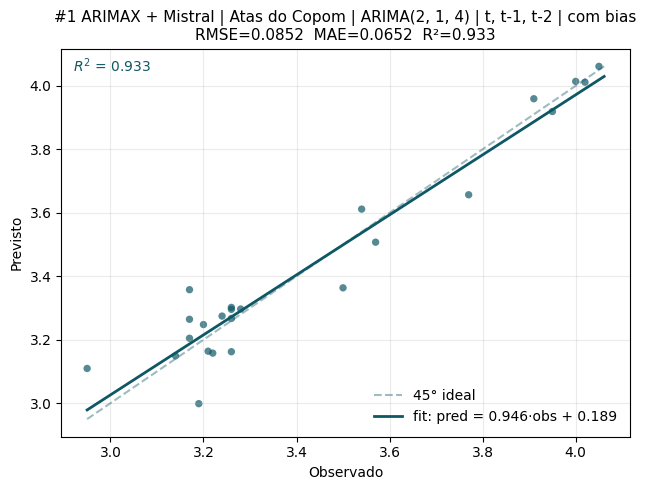

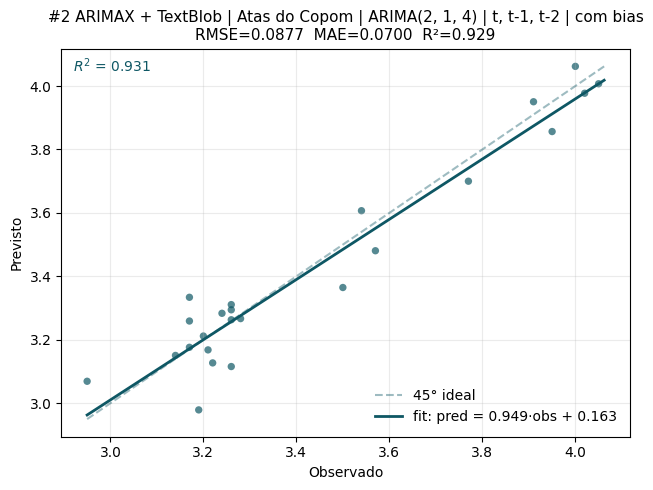

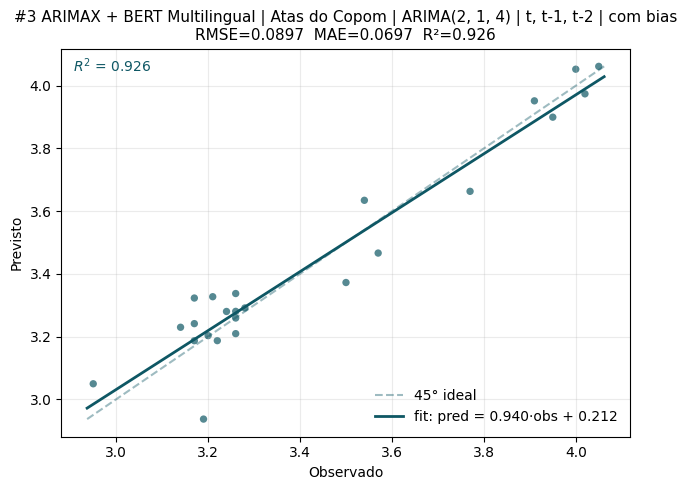


  SVR — top 3 (Atas do Copom, com bias)


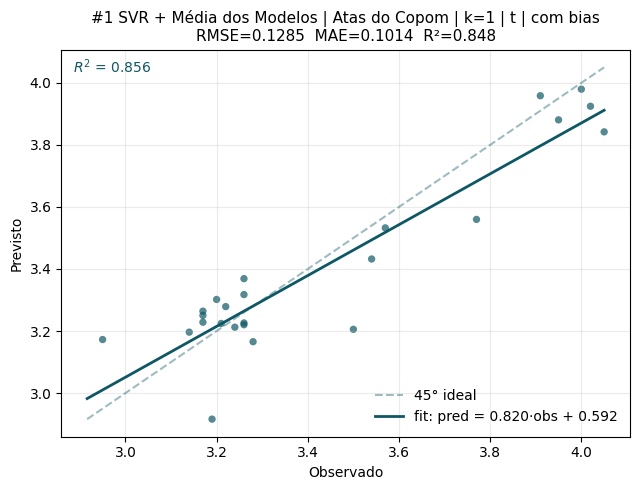

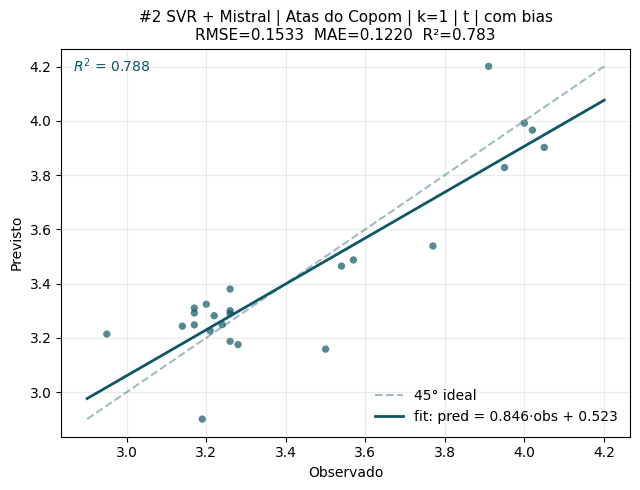

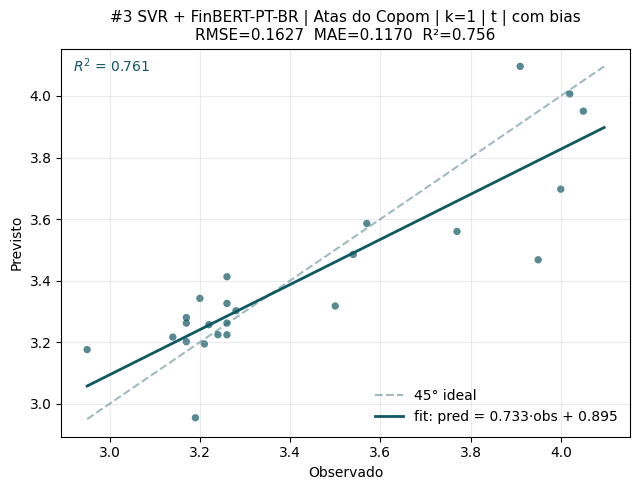


  XGBoost — top 3 (Atas do Copom, com bias)


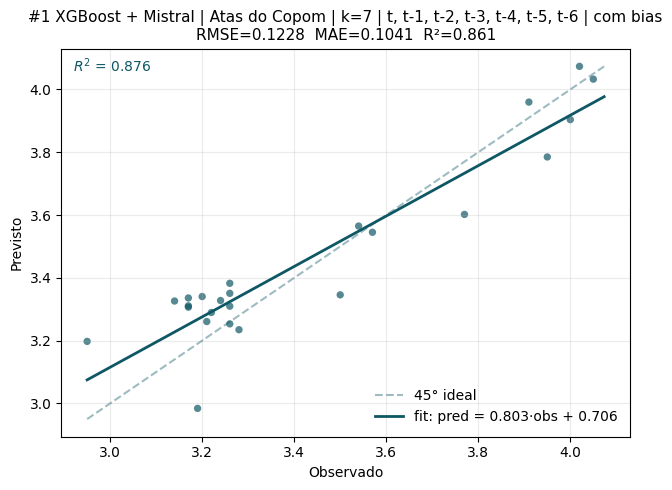

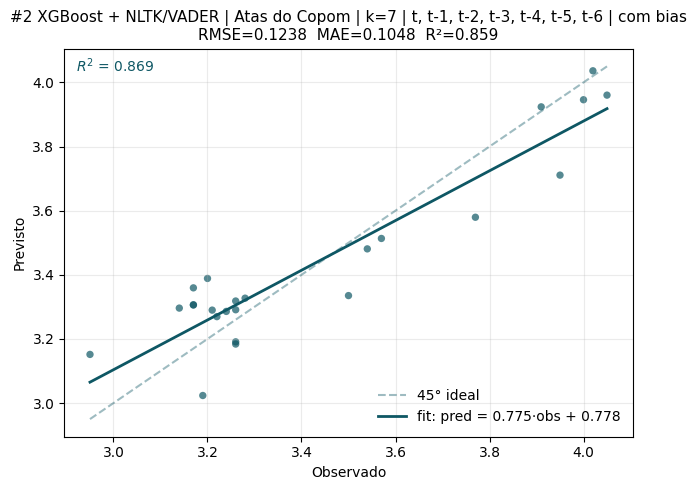

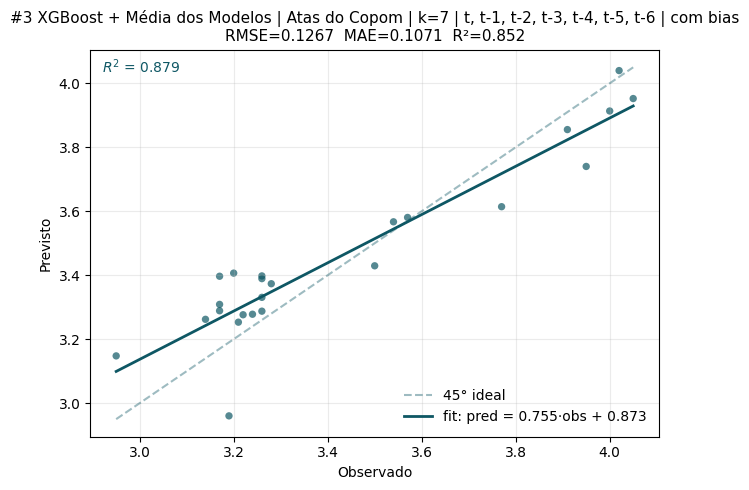


  ARIMAX — top 3 (Relatórios de Estatísticas, com bias)


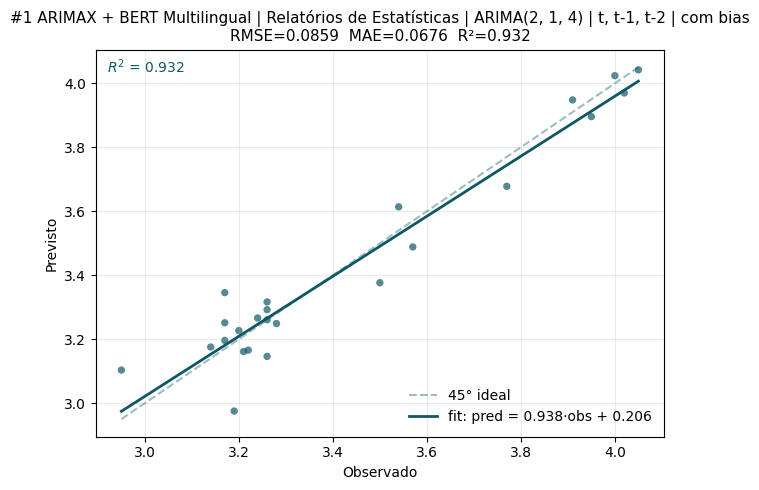

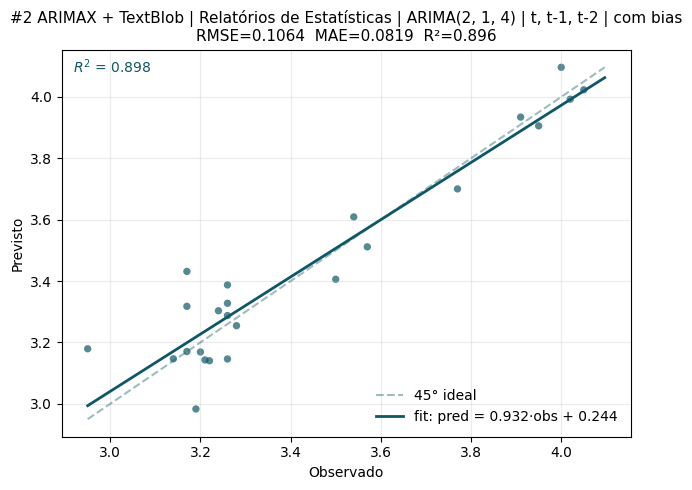

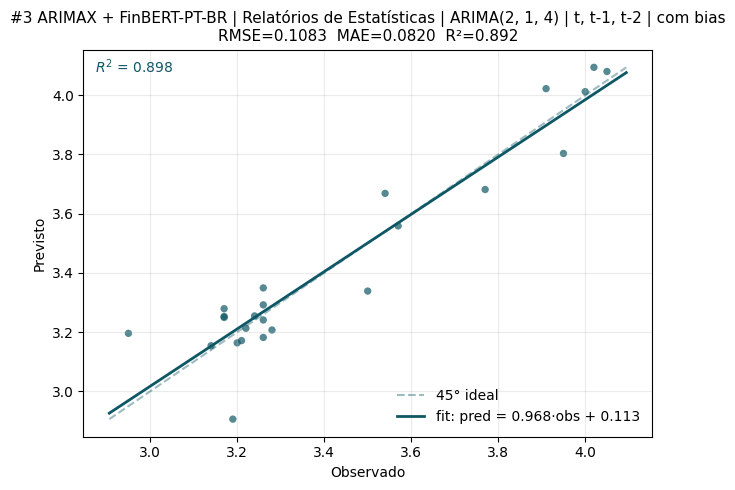


  SVR — top 3 (Relatórios de Estatísticas, com bias)


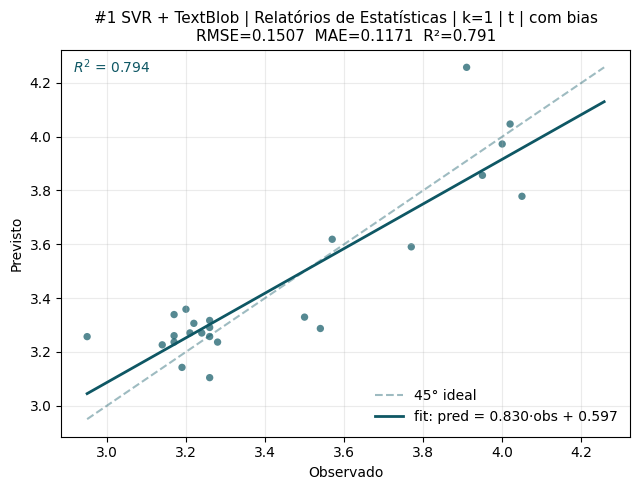

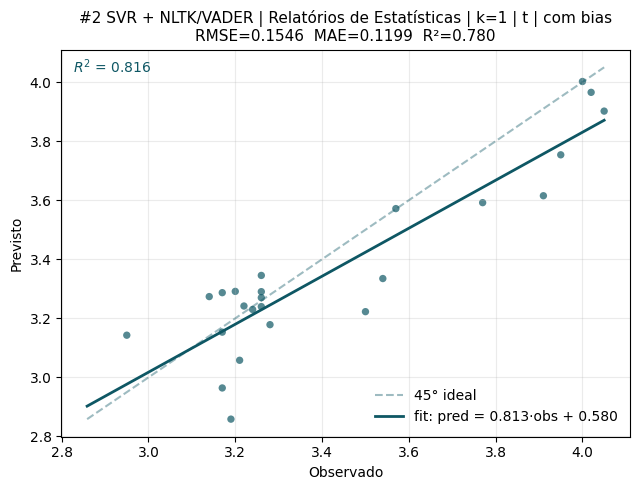

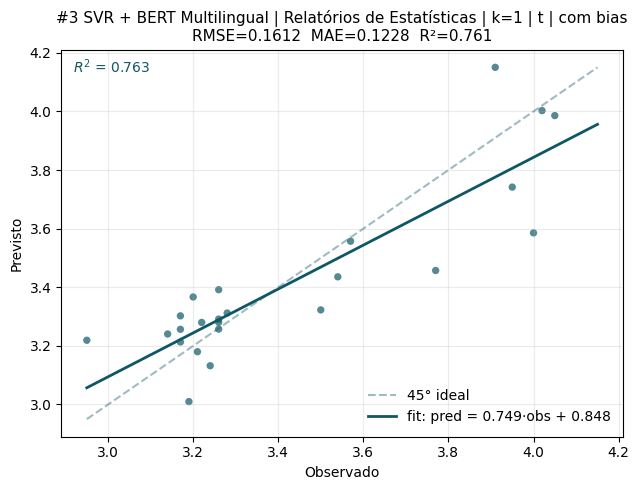


  XGBoost — top 3 (Relatórios de Estatísticas, com bias)


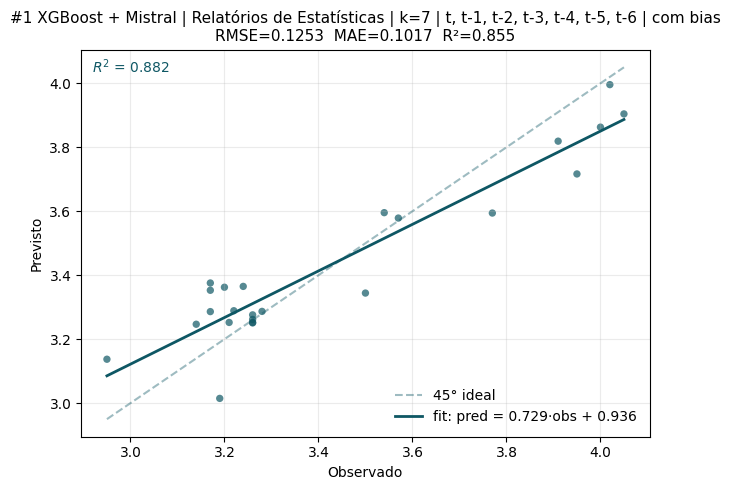

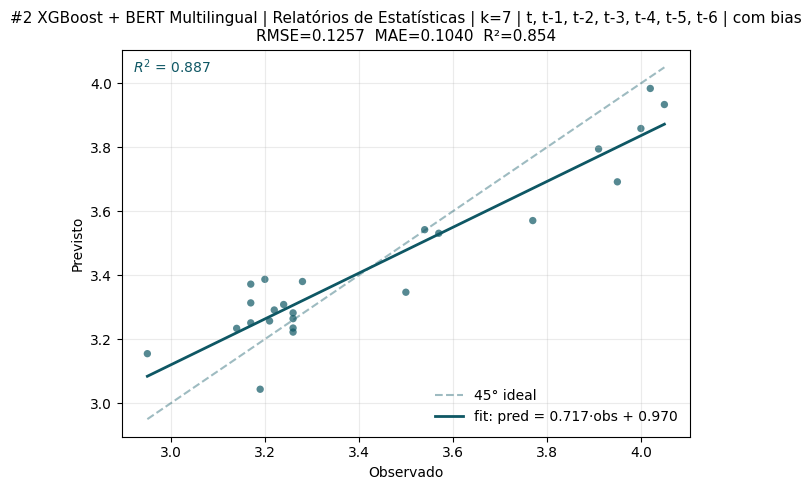

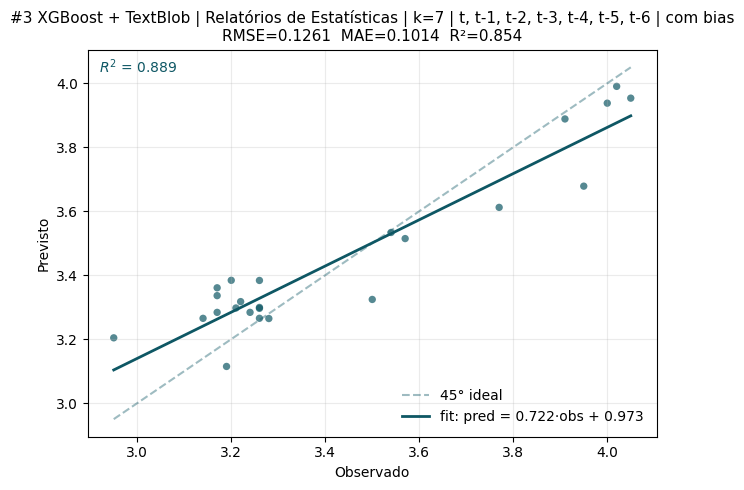

In [23]:
# Cor padrão — mesma do Notebook 02
COLOR = "#0e5764"


def plot_regressao(y_true, y_pred, titulo):
    """
    Gráfico previsto vs. observado no padrão do Notebook 02:
    - Cor única (#0e5764)
    - Linha de 45° tracejada (ideal)
    - Reta de regressão ajustada
    - R² anotado no painel (sem bbox)
    - Grade suave e legenda sem borda
    """
    df_plot = pd.concat([
        pd.Series(y_true).rename("obs"),
        pd.Series(y_pred).rename("pred"),
    ], axis=1).dropna()

    if df_plot.empty:
        raise ValueError("Não há observações suficientes para gerar o gráfico.")

    x = df_plot["obs"].values.reshape(-1, 1)
    y = df_plot["pred"].values

    lr = LinearRegression().fit(x, y)
    r2 = lr.score(x, y)
    slope = float(lr.coef_[0])
    intercept = float(lr.intercept_)

    xy_min = float(min(df_plot["obs"].min(), df_plot["pred"].min()))
    xy_max = float(max(df_plot["obs"].max(), df_plot["pred"].max()))
    xx = np.linspace(xy_min, xy_max, 100)

    plt.figure(figsize=(6.5, 5))

    plt.scatter(
        df_plot["obs"],
        df_plot["pred"],
        s=28,
        alpha=0.7,
        edgecolors="none",
        color=COLOR,
    )

    plt.plot(
        [xy_min, xy_max],
        [xy_min, xy_max],
        "--",
        lw=1.5,
        alpha=0.4,
        color=COLOR,
        label="45° ideal",
    )

    plt.plot(
        xx,
        slope * xx + intercept,
        lw=2.0,
        color=COLOR,
        label=f"fit: pred = {slope:.3f}·obs + {intercept:.3f}",
    )

    plt.title(titulo, fontsize=11)
    plt.xlabel("Observado")
    plt.ylabel("Previsto")
    plt.grid(True, alpha=0.25)
    plt.legend(frameon=False)

    plt.text(
        0.02,
        0.98,
        f"$R^2$ = {r2:.3f}",
        transform=plt.gca().transAxes,
        ha="left",
        va="top",
        fontsize=10,
        color=COLOR,
    )

    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────
# Loop: top 3 por família e por tipo de relatório (com bias)
# ─────────────────────────────────────────────────────────────
for tipo in sorted(top3_todos["Tipo Relatório"].unique()):
    for familia in sorted(top3_todos["Família"].unique()):
        subset = (
            top3_todos[
                (top3_todos["Tipo Relatório"] == tipo) &
                (top3_todos["Família"] == familia)
            ]
            .sort_values("RMSE")
        )
        if subset.empty:
            continue
        print(f"\n{'='*60}")
        print(f"  {familia} — top 3 ({tipo}, com bias)")
        print(f"{'='*60}")
        for rank, (_, row) in enumerate(subset.iterrows(), start=1):
            pred_id = row["id_predicao"]
            info = predicoes_teste[pred_id]
            titulo = (
                f"#{rank} {row['Família']} + {row['Modelo Sentimento']} "
                f"| {row['Tipo Relatório']} | {row['Configuração']} | {row['Janela Sentimento']} | com bias\n"
                f"RMSE={row['RMSE']:.4f}  MAE={row['MAE']:.4f}  R²={row['R2']:.3f}"
            )
            plot_regressao(info["y_true"], info["y_pred"], titulo)

## 11. Leitura metodológica para o artigo

Nesta etapa, os modelos com sentimento foram estimados sem nova busca de lags para os scores textuais. A janela de sentimento foi definida por paralelismo com a estrutura temporal da inadimplência já definida no Notebook 02.

Para o ARIMAX, manteve-se a ordem `ARIMA(2,1,4)`. Como a componente autorregressiva possui `p=2`, cada série de sentimento foi incorporada com três informações temporais: sentimento em `t`, `t-1` e `t-2`. Para os modelos tabulares, a mesma lógica foi aplicada conforme o valor de `k`: o SVR, com `k=1`, usa a inadimplência em `t` e o sentimento em `t`; o XGBoost, com `k=7`, usa a inadimplência de `t` até `t-6` e o sentimento de `t` até `t-6`.

Além disso, cada série de sentimento foi avaliada separadamente. Essa escolha evita que muitos scores textuais entrem simultaneamente no mesmo modelo, reduzindo o risco de sobrecarga de variáveis em uma amostra mensal relativamente curta e permitindo comparar, de forma mais transparente, quais combinações entre tipo de documento e modelo de sentimento apresentam melhor desempenho preditivo.

A comparação substantiva do ganho ou perda de desempenho causado pela inclusão de sentimento deve ser feita no Notebook 07, confrontando os resultados deste notebook com os modelos sem sentimento do Notebook 02 sob as mesmas métricas: MAE, RMSE, R², bias e alinhamento previsto versus observado.


In [24]:
# ─────────────────────────────────────────────────────────────
# EXPORTAÇÃO — resultados_com_sentimento.csv
# Cole esta célula ao final do Notebook 06, após a seção 10
# (gráficos previsto vs. observado).
# ─────────────────────────────────────────────────────────────
# Exporta o top 3 por família E por tipo de relatório
# (com e sem bias) com todas as colunas de métricas.

CAMINHO_EXPORT_NB06 = "resultados_com_sentimento.csv"

_COLS_EXPORT = [
    "Família",
    "Tipo Relatório",
    "Modelo Sentimento",
    "Série Sentimento",
    "Configuração",
    "Janela Sentimento",
    "Com bias",
    "Bias estimado treino",
    "MAE",
    "RMSE",
    "R2",
    "Bias (obs - prev)",
    "Slope pred~obs",
    "Intercept",
    "N",
    "id_predicao",
]

# Top 3 por família e por tipo de relatório, com bias
_top3_com = (
    comparativo_com_sentimento
    .query("`Com bias` == 'Sim'")
    .sort_values(["Tipo Relatório", "Família", "RMSE"])
    .groupby(["Tipo Relatório", "Família"], sort=False)
    .head(3)
    .reset_index(drop=True)
)

# Versão sem bias das mesmas séries selecionadas acima
_top3_sem = (
    comparativo_com_sentimento
    .query("`Com bias` == 'Não'")
    .merge(
        _top3_com[["Tipo Relatório", "Família", "Série Sentimento"]],
        on=["Tipo Relatório", "Família", "Série Sentimento"],
        how="inner",
    )
)

export_nb06 = (
    pd.concat([_top3_com, _top3_sem], ignore_index=True)
    .sort_values(["Tipo Relatório", "Família", "Série Sentimento", "Com bias"])
    .reset_index(drop=True)
)

# Rank local (1-3) por Tipo Relatório × Família, baseado na versão com bias
_rank_map = (
    _top3_com[["Tipo Relatório", "Família", "Série Sentimento"]]
    .copy()
    .assign(Rank=lambda df: df.groupby(["Tipo Relatório", "Família"]).cumcount() + 1)
)
export_nb06 = export_nb06.merge(
    _rank_map,
    on=["Tipo Relatório", "Família", "Série Sentimento"],
    how="left",
)

# Reordena colunas
_cols_final = ["Rank"] + [c for c in _COLS_EXPORT if c in export_nb06.columns]
export_nb06[_cols_final].to_csv(CAMINHO_EXPORT_NB06, index=False)

n_tipos    = export_nb06["Tipo Relatório"].nunique()
n_familias = export_nb06["Família"].nunique()
print(f"✅ Exportado: {CAMINHO_EXPORT_NB06}")
print(f"   Linhas: {len(export_nb06)}  (top 3 × {n_tipos} relatórios × {n_familias} famílias × 2 versões bias = até {3*n_tipos*n_familias*2} linhas)")
display(export_nb06[_cols_final].round(6))

✅ Exportado: resultados_com_sentimento.csv
   Linhas: 36  (top 3 × 2 relatórios × 3 famílias × 2 versões bias = até 36 linhas)


,Rank,Família,Tipo Relatório,Modelo Sentimento,Série Sentimento,Configuração,Janela Sentimento,Com bias,Bias estimado treino,MAE,RMSE,R2,Bias (obs - prev),Slope pred~obs,Intercept,N,id_predicao
0,3,ARIMAX,Atas do Copom,BERT Multilingual,copom_score_bert,"ARIMA(2, 1, 4)","t, t-1, t-2",Não,NaN,0.067838,0.090813,0.924017,0.015340,0.939685,0.191466,24,ARIMAX|copom_score_bert|sem_bias
1,3,ARIMAX,Atas do Copom,BERT Multilingual,copom_score_bert,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.020629,0.069656,0.089664,0.925927,-0.005289,0.939685,0.212095,24,ARIMAX|copom_score_bert|com_bias
2,1,ARIMAX,Atas do Copom,Mistral,copom_score_mistral,"ARIMA(2, 1, 4)","t, t-1, t-2",Não,NaN,0.063953,0.087210,0.929925,0.018834,0.945532,0.167922,24,ARIMAX|copom_score_mistral|sem_bias
3,1,ARIMAX,Atas do Copom,Mistral,copom_score_mistral,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.021556,0.065200,0.085196,0.933125,-0.002722,0.945532,0.189478,24,ARIMAX|copom_score_mistral|com_bias
4,2,ARIMAX,Atas do Copom,TextBlob,copom_score_textblob,"ARIMA(2, 1, 4)","t, t-1, t-2",Não,NaN,0.070546,0.090270,0.924921,0.024355,0.949129,0.150068,24,ARIMAX|copom_score_textblob|sem_bias
5,2,ARIMAX,Atas do Copom,TextBlob,copom_score_textblob,"ARIMA(2, 1, 4)","t, t-1, t-2",Sim,0.012900,0.069984,0.087674,0.929177,0.011456,0.949129,0.162968,24,ARIMAX|copom_score_textblob|com_bias
6,3,SVR,Atas do Copom,FinBERT-PT-BR,copom_score_finbert,k=1,t,Não,NaN,0.117231,0.166425,0.744809,0.040470,0.732933,0.875237,24,SVR|copom_score_finbert|sem_bias
7,3,SVR,Atas do Copom,FinBERT-PT-BR,copom_score_finbert,k=1,t,Sim,0.020070,0.117031,0.162714,0.756065,0.020399,0.732933,0.895307,24,SVR|copom_score_finbert|com_bias
8,1,SVR,Atas do Copom,Média dos Modelos,copom_score_media,k=1,t,Não,NaN,0.102139,0.130475,0.843151,0.034791,0.819569,0.583862,24,SVR|copom_score_media|sem_bias
9,1,SVR,Atas do Copom,Média dos Modelos,copom_score_media,k=1,t,Sim,0.008470,0.101433,0.128476,0.847920,0.026321,0.819569,0.592332,24,SVR|copom_score_media|com_bias
